In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [2]:
import numpy as np
np.random.seed(42)

N = 2000
X = np.random.uniform(-3, 3, (N, 3))
x1 = X[:, 0]
x2 = X[:, 1]
x3 = X[:, 2]

# Nonlinear deterministic function
Y = np.sin(x1) + x2**2 + np.log(1 + np.abs(x3)) + 0.5 * x1 * x3
Y = Y.reshape(-1, 1)

print(f"X shape: {X.shape}")
print(f"Y shape: {Y.shape}")

X shape: (2000, 3)
Y shape: (2000, 1)


In [3]:
class NumPyDNN:
    def __init__(self, input_dim=3, hidden1=64, hidden2=32, output_dim=1, learning_rate=0.01):
        self.lr = learning_rate
        # Weights and biases initialization
        self.W1 = np.random.randn(input_dim, hidden1) * 0.1
        self.b1 = np.zeros((1, hidden1))
        self.W2 = np.random.randn(hidden1, hidden2) * 0.1
        self.b2 = np.zeros((1, hidden2))
        self.W3 = np.random.randn(hidden2, output_dim) * 0.1
        self.b3 = np.zeros((1, output_dim))

    def relu(self, Z):
        return np.maximum(0, Z)

    def relu_derivative(self, Z):
        return (Z > 0).astype(float)

    def forward(self, X):
        self.X = X
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = self.relu(self.Z1)

        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = self.relu(self.Z2)

        self.Z3 = np.dot(self.A2, self.W3) + self.b3
        self.A3 = self.Z3 # Linear output
        return self.A3

    def backward(self, Y):
        N = Y.shape[0]

        dZ3 = (2 / N) * (self.A3 - Y)
        dW3 = np.dot(self.A2.T, dZ3)
        db3 = np.sum(dZ3, axis=0, keepdims=True)

        dA2 = np.dot(dZ3, self.W3.T)
        dZ2 = dA2 * self.relu_derivative(self.Z2)
        dW2 = np.dot(self.A1.T, dZ2)
        db2 = np.sum(dZ2, axis=0, keepdims=True)

        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = dA1 * self.relu_derivative(self.Z1)
        dW1 = np.dot(self.X.T, dZ1)
        db1 = np.sum(dZ1, axis=0, keepdims=True)

        self.W3 -= self.lr * dW3
        self.b3 -= self.lr * db3
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    def get_loss(self, Y):
        return np.mean((self.A3 - Y) ** 2)

In [4]:
model = NumPyDNN(learning_rate=0.01)
epochs = 1000
losses = []

for epoch in range(epochs):
    predictions = model.forward(X)
    loss = model.get_loss(Y)
    losses.append(loss)
    model.backward(Y)

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Loss: {loss:.4f}")

Epoch 100/1000 - Loss: 0.7442
Epoch 200/1000 - Loss: 0.4323
Epoch 300/1000 - Loss: 0.3483
Epoch 400/1000 - Loss: 0.2964
Epoch 500/1000 - Loss: 0.2558
Epoch 600/1000 - Loss: 0.2230
Epoch 700/1000 - Loss: 0.1980
Epoch 800/1000 - Loss: 0.1780
Epoch 900/1000 - Loss: 0.1615
Epoch 1000/1000 - Loss: 0.1472


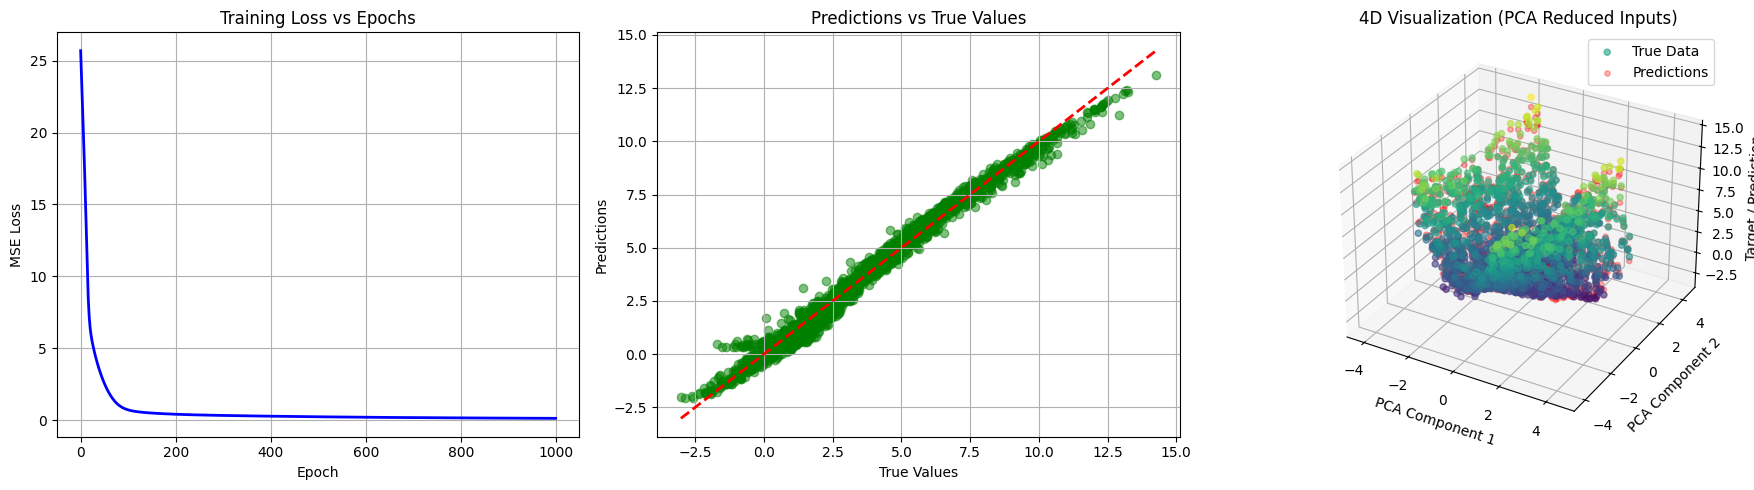

In [5]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

fig = plt.figure(figsize=(18, 5))

# Plot 1: Loss vs Epochs
ax1 = fig.add_subplot(1, 3, 1)
ax1.plot(losses, color='blue', linewidth=2)
ax1.set_title("Training Loss vs Epochs")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("MSE Loss")
ax1.grid(True)

# Plot 2: Predictions vs True Values
ax2 = fig.add_subplot(1, 3, 2)
ax2.scatter(Y, predictions, alpha=0.5, color='green')
ax2.plot([Y.min(), Y.max()], [Y.min(), Y.max()], 'r--', lw=2)
ax2.set_title("Predictions vs True Values")
ax2.set_xlabel("True Values")
ax2.set_ylabel("Predictions")
ax2.grid(True)

# Plot 3: 4D Visualization using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

ax3 = fig.add_subplot(1, 3, 3, projection='3d')
sc = ax3.scatter(X_pca[:, 0], X_pca[:, 1], Y.flatten(), c=Y.flatten(), cmap='viridis', alpha=0.6, label='True Data')
ax3.scatter(X_pca[:, 0], X_pca[:, 1], predictions.flatten(), color='red', alpha=0.3, s=15, label='Predictions')
ax3.set_title("4D Visualization (PCA Reduced Inputs)")
ax3.set_xlabel("PCA Component 1")
ax3.set_ylabel("PCA Component 2")
ax3.set_zlabel("Target / Prediction")
ax3.legend()

plt.tight_layout()
plt.show()